In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk


plt.style.use("default")  # keep simple


# Use 'r' before the path and fix the quotes
file_path = r'C:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\data\raw\reviews.csv'

# Load the dataset
df = pd.read_csv(file_path, index_col=0)

#save the result plot
import os

os.makedirs("data/processed", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

1.Basic Dataset Understanding


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())


Shape: (23486, 10)

Columns:
 Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

Missing values:
 Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


titles are missing titles missing and it is like 

🔹 2. Rating Distribution (IMPORTANT)

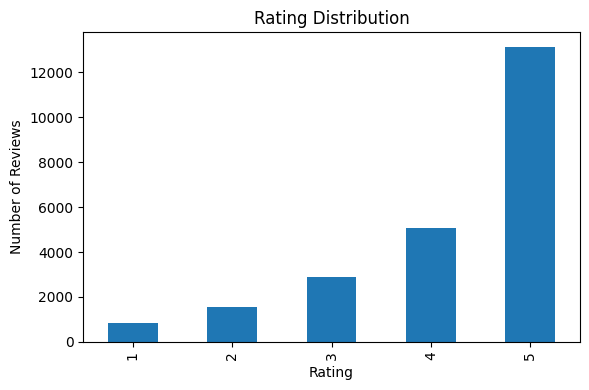

In [3]:
plt.figure(figsize=(6,4))
df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/rating_distribution.png")
plt.show()

🔹 3. Convert Rating → Sentiment

In [4]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["Rating"].apply(rating_to_sentiment)

df["sentiment"].value_counts()



sentiment
positive    18208
neutral      2871
negative     2407
Name: count, dtype: int64

4. sentimental analysis

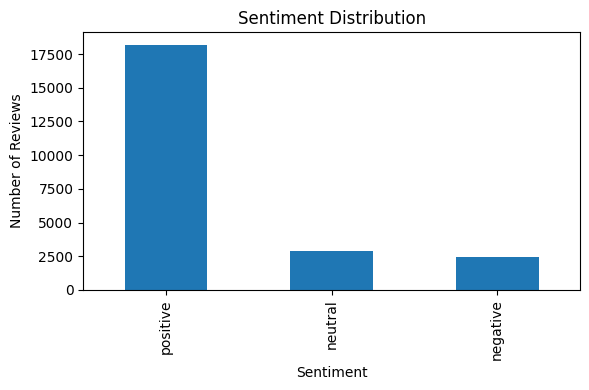

In [5]:
plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/sentiment_distribution.png")
plt.show()


🔹 5. Review Length Analysis

In [6]:
df["char_length"] = df["Review Text"].fillna("").apply(len)
df["word_count"] = df["Review Text"].fillna("").apply(lambda x: len(x.split()))
df[["Review Text", "char_length", "word_count"]].head()

,Review Text,char_length,word_count
0,Absolutely wonderful - silky and sexy and comf...,53,8
1,Love this dress! it's sooo pretty. i happene...,303,62
2,I had such high hopes for this dress and reall...,500,98
3,"I love, love, love this jumpsuit. it's fun, fl...",124,22
4,This shirt is very flattering to all due to th...,192,36


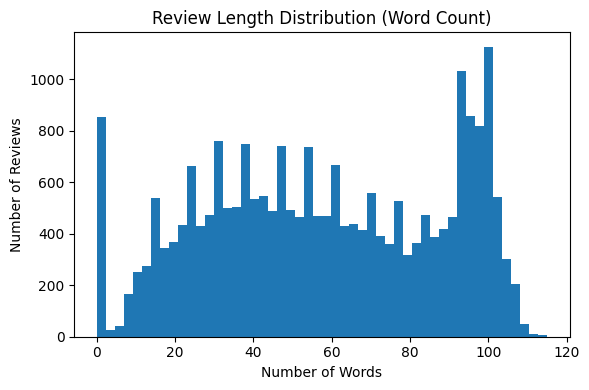

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["word_count"], bins=50)

plt.title("Review Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/review_length_distribution.png")
plt.show()


6. Review Length vs Sentiment

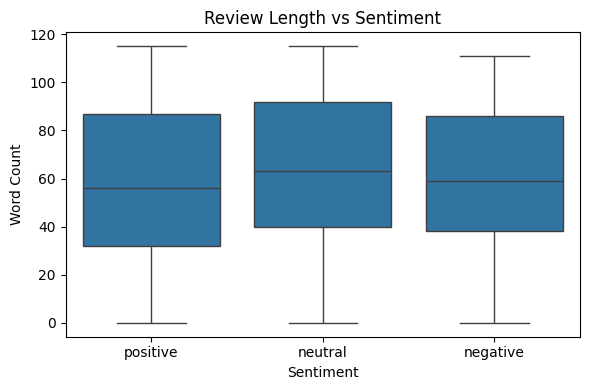

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="word_count", data=df)

plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig("results/figures/review_length_vs_sentiment.png")
plt.show()


7. Word Cloud (Text Understanding)

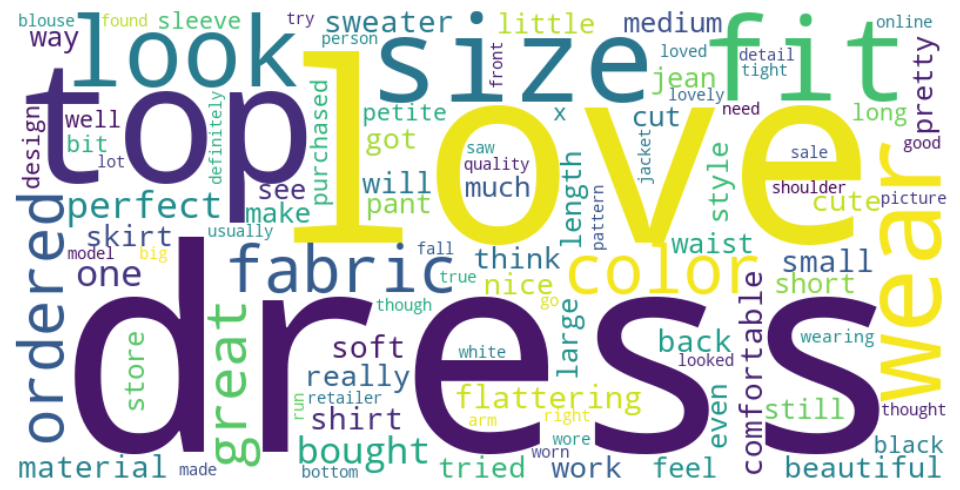

In [9]:
text = " ".join(df["Review Text"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("results/figures/wordcloud.png")
plt.show()


8. Manual Review Inspection (CRITICAL)

In [10]:
print("POSITIVE REVIEWS:\n")
for review in df[df["sentiment"] == "positive"]["Review Text"].sample(5):
    print(review)
    print("-" * 60)

print("\nNEGATIVE REVIEWS:\n")
for review in df[df["sentiment"] == "negative"]["Review Text"].sample(5):
    print(review)
    print("-" * 60)


POSITIVE REVIEWS:

Bought this for my girlfriend and she couldn't be happier! she's a size 4/34c and the small fits perfectly and is so flattering and comfortable. highly recommend.
------------------------------------------------------------
Lovely statement shift. sweet and sophisticated at the same time. the lightweight knit drapes nicely over one's figure. my store showed it paired with a collared cream-white blouse for alternative styling. i know i'll be experimenting with solid tees.
------------------------------------------------------------
This skirt is stunning but i really wish it was cotton canvas - maybe by summer retailer could make one?
------------------------------------------------------------
I didn't go with the intention of even looking at a dress, but decided to try this on. once i did, i knew that i had to get it. it's so cute. i got the one listed as green motif, which is actually a royal blue bodice. the colors are vibrant and it's so comfortable.
------------

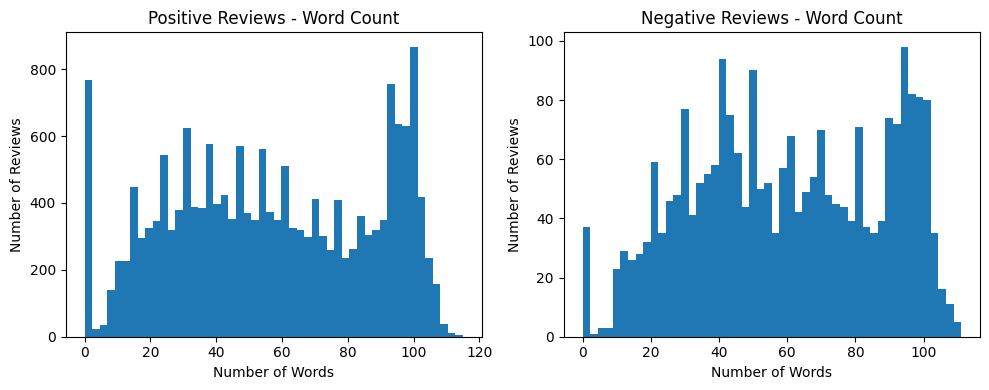

In [11]:
df["word_count"] = df["Review Text"].fillna("").apply(lambda x: len(x.split()))
plt.figure(figsize=(10,4))

# Positive reviews
plt.subplot(1, 2, 1)
plt.hist(
    df[df["sentiment"] == "positive"]["word_count"],
    bins=50
)
plt.title("Positive Reviews - Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

# Negative reviews
plt.subplot(1, 2, 2)
plt.hist(
    df[df["sentiment"] == "negative"]["word_count"],
    bins=50
)
plt.title("Negative Reviews - Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()



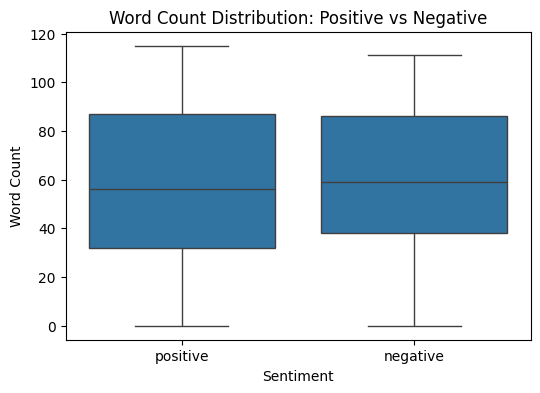

In [12]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="sentiment",
    y="word_count",
    data=df[df["sentiment"].isin(["positive", "negative"])]
)

plt.title("Word Count Distribution: Positive vs Negative")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()


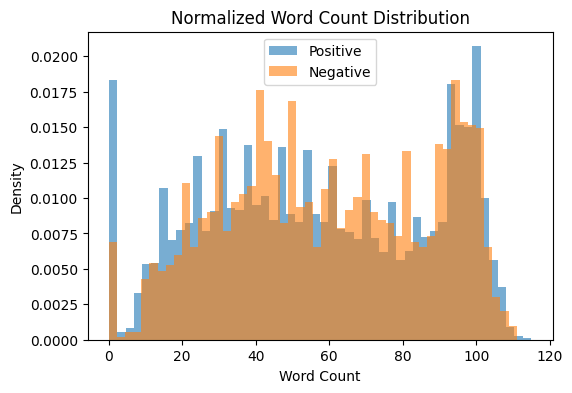

In [13]:
plt.figure(figsize=(6,4))

plt.hist(
    df[df["sentiment"] == "positive"]["word_count"],
    bins=50,
    alpha=0.6,
    label="Positive",
    density=True
)

plt.hist(
    df[df["sentiment"] == "negative"]["word_count"],
    bins=50,
    alpha=0.6,
    label="Negative",
    density=True
)

plt.title("Normalized Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.show()


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
now at the 1.4

In [14]:
import re
import pandas as pd
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


text_col = "Review Text"
df[text_col] = df[text_col].fillna("")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


STEP 3: Basic text cleaning function (CORE) and apply cleaning 

In [15]:
def basic_clean(text):
    text = text.lower()                      # normalize case
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)    # keep letters only
    text = re.sub(r"\s+", " ", text)         # remove extra spaces
    return text.strip()

#apply the cleaning function
df["clean_text"] = df["Review Text"].fillna("").apply(basic_clean)


STEP 5: Tokenization

In [16]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())




STEP 6: Stopwords (VERY CAREFUL STEP ⚠️)

In [17]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# VERY IMPORTANT: keep negations
negations = {"not", "no", "nor", "never"}
stop_words = stop_words - negations

#Now remove stopwords:
df["tokens"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)


STEP 7: Lemmatization (YES), Stemming (NO)

In [18]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)


STEP 8: Rebuild cleaned text  /////final steps

In [44]:

df["final_text"] = df["tokens"].apply(lambda x: " ".join(x))
#sanity check
df[[text_col, "final_text"]].sample(5)
#save the processed data


file_path = r'C:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\data\proceeded\"cleaned_reviews.csv"'
df[["final_text", "sentiment"]].to_csv(    
index=False
)



'final_text,sentiment\r\nabsolutely wonderful silky sexy comfortable,positive\r\nlove dress sooo pretty happened find store glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,positive\r\nhigh hope dress really wanted work initially ordered petite small usual size found outrageously small small fact could not zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight layer several somewhat cheap net layer imo major design flaw net layer sewn directly zipper c,neutral\r\nlove love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,positive\r\nshirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,positive\r\nlove tracy reese dress one not petite foot tall usually wear p brand dress pretty package lot dress skirt long full overwhelmed small frame not stranger alteration shortening narrowing ski